In [1]:
%pip install networkx matplotlib

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create weighted graph

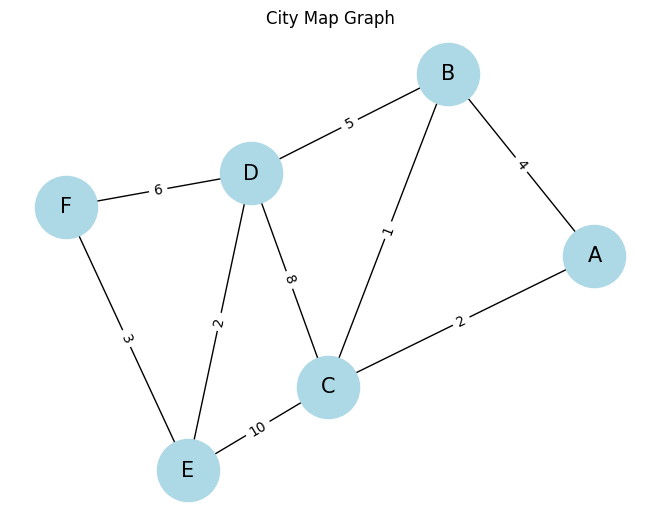

In [3]:
#Create a graph to represent the map
G = nx.Graph()


#Add nodes (cities, locations,etc)
G.add_nodes_from(["A", "B", "C", "D", "E", "F"])


#Add weighted edges (distances between cities)
edges = [
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 1),
    ("B", "D", 5),
    ("C", "D", 8),
    ("C", "E", 10),
    ("D", "E", 2),
    ("D", "F", 6),
    ("E", "F", 3)
]
G.add_weighted_edges_from(edges)



#Visualize the graph
pos = nx.spring_layout(G, seed=42)  #Layout for consistent visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("City Map Graph")
plt.show()

# Find the shortest path using Dijkstra's Algorithm

In [4]:
dijkstra_path = nx.dijkstra_path(G, source="A", target="F", weight="weight")
print("Dijkstra’s shortest path from A to F:", dijkstra_path)

Dijkstra’s shortest path from A to F: ['A', 'C', 'B', 'D', 'E', 'F']


# Find the shortest path using A* Search

In [5]:
#Made-up heuristic: "straight-line distance" (fake values for illustration)
heuristic = {
    "A": 7,
    "B": 6,
    "C": 2,
    "D": 1,
    "E": 1,
    "F": 0
}

#Heuristic function
def heuristic_fn(n1, n2):
    return heuristic[n1]

a_star_path = nx.astar_path(G, source="A", target="F", heuristic=heuristic_fn, weight="weight")
print("A* shortest path from A to F:", a_star_path)

A* shortest path from A to F: ['A', 'C', 'B', 'D', 'E', 'F']


# What if we want a more complex heuristic?

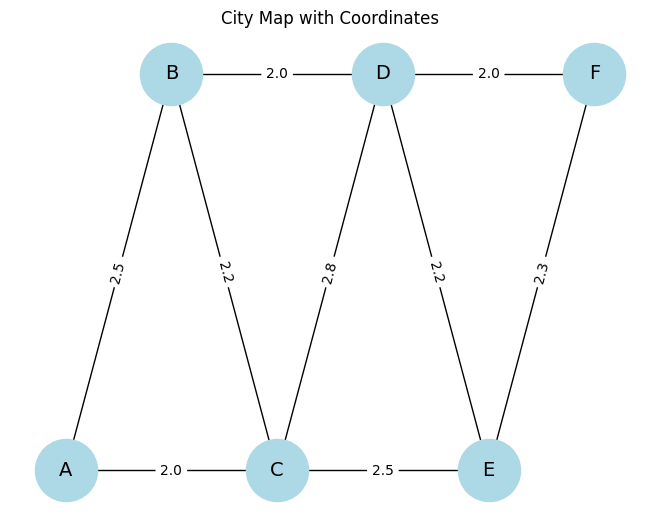

In [6]:
import math

#Create a graph
G = nx.Graph()

#Define nodes and their (x, y) positions on a grid
positions = {
    "A": (0, 0),
    "B": (1, 2),
    "C": (2, 0),
    "D": (3, 2),
    "E": (4, 0),
    "F": (5, 2)
}
G.add_nodes_from(positions.keys())

#Add weighted edges (e.g., road distances in arbitrary units)
edges = [
    ("A", "B", 2.5),
    ("A", "C", 2.0),
    ("B", "C", 2.2),
    ("B", "D", 2.0),
    ("C", "D", 2.8),
    ("C", "E", 2.5),
    ("D", "E", 2.2),
    ("D", "F", 2.0),
    ("E", "F", 2.3)
]
G.add_weighted_edges_from(edges)

#Visualize the graph
nx.draw(G, positions, with_labels=True, node_color='lightblue', node_size=2000, font_size=14)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels)
plt.title("City Map with Coordinates")
plt.show()

In [7]:
#Define the coordinate-based heuristic function (Euclidean distance)
def euclidean_heuristic(n1, n2):
    x1, y1 = positions[n1]
    x2, y2 = positions[n2]
    return math.hypot(x2 - x1, y2 - y1)


#Run A* with the Euclidean heuristic
a_star_path = nx.astar_path(G, source="A", target="F", heuristic=euclidean_heuristic, weight="weight")
print("A* shortest path from A to F using Euclidean heuristic:", a_star_path)

A* shortest path from A to F using Euclidean heuristic: ['A', 'B', 'D', 'F']


# Experiments

## Practice 1:  is there a shorter path than A-B-D-F?

At the end of the video we were asked to check if there is an even shorter path. I am listing all possible paths from A to F with their total cost to check.

In [8]:
#List every possible path from A to F and calculate its total cost
for path in nx.all_simple_paths(G, source="A", target="F"):
    cost = 0
    for i in range(len(path) - 1):
        cost = cost + G[path[i]][path[i + 1]]["weight"]
    print(path, "cost =", round(cost, 1))

['A', 'B', 'C', 'D', 'E', 'F'] cost = 12.0
['A', 'B', 'C', 'D', 'F'] cost = 9.5
['A', 'B', 'C', 'E', 'D', 'F'] cost = 11.4
['A', 'B', 'C', 'E', 'F'] cost = 9.5
['A', 'B', 'D', 'C', 'E', 'F'] cost = 12.1
['A', 'B', 'D', 'E', 'F'] cost = 9.0
['A', 'B', 'D', 'F'] cost = 6.5
['A', 'C', 'B', 'D', 'E', 'F'] cost = 10.7
['A', 'C', 'B', 'D', 'F'] cost = 8.2
['A', 'C', 'D', 'E', 'F'] cost = 9.3
['A', 'C', 'D', 'F'] cost = 6.8
['A', 'C', 'E', 'D', 'F'] cost = 8.7
['A', 'C', 'E', 'F'] cost = 6.8


So A-B-D-F with cost 6.5 is really the best. The next best paths cost 6.8. No shorter path exists.

## Practice 2: Checking if the Euclidean heuristic is admissible

In the reading, a heuristic is admissible if it never overestimates the actual cost to the goal. For every node I am comparing the straight line distance to F with the actual shortest road distance to F.

In [9]:
for node in G.nodes:
    h = euclidean_heuristic(node, "F")
    actual = nx.dijkstra_path_length(G, node, "F", weight="weight")
    print(node, ": h =", round(h, 2), ", actual =", round(actual, 2), ", admissible =", h <= actual)

A : h = 5.39 , actual = 6.5 , admissible = True
B : h = 4.0 , actual = 4.0 , admissible = True
C : h = 3.61 , actual = 4.8 , admissible = True
D : h = 2.0 , actual = 2.0 , admissible = True
E : h = 2.24 , actual = 2.3 , admissible = True
F : h = 0.0 , actual = 0 , admissible = True


The heuristic is admissible for every node, which is why A\* is guaranteed to find the optimal path here.

## Practice 3: BFS vs Dijkstra

BFS ignores weights and only counts the number of edges. I want to see if that gives a different (worse) answer.

In [10]:
bfs_path = nx.shortest_path(G, source="A", target="F")  #no weight, so plain BFS
bfs_cost = 0
for i in range(len(bfs_path) - 1):
    bfs_cost = bfs_cost + G[bfs_path[i]][bfs_path[i + 1]]["weight"]

print("BFS path:", bfs_path, "cost =", round(bfs_cost, 1))
print("Dijkstra path:", nx.dijkstra_path(G, "A", "F", weight="weight"),
      "cost =", nx.dijkstra_path_length(G, "A", "F", weight="weight"))

BFS path: ['A', 'B', 'D', 'F'] cost = 6.5
Dijkstra path: ['A', 'B', 'D', 'F'] cost = 6.5


Here BFS actually found the same path, because the best path A-B-D-F also happens to have the fewest edges (3). But this is just luck — if the weights were different, BFS could easily pick a worse path since it does not look at weights at all.

## Practice 4: What if there is a traffic jam on B-D?

In real life road costs change. I am increasing the weight of the B-D edge (like a traffic jam) and running A\* again to see if the route changes.

In [11]:
G["B"]["D"]["weight"] = 10.0  #traffic jam! was 2.0 before

new_path = nx.astar_path(G, source="A", target="F", heuristic=euclidean_heuristic, weight="weight")
new_cost = nx.dijkstra_path_length(G, "A", "F", weight="weight")
print("New best path:", new_path, "cost =", round(new_cost, 1))

G["B"]["D"]["weight"] = 2.0  #putting it back to normal

New best path: ['A', 'C', 'E', 'F'] cost = 6.8


The route changed — A\* now avoids the B-D road and goes through C instead. This is basically what GPS apps do when they re-route around traffic.